# 21 — Broadcast-Only Reach Asymmetry (single policy, peers off)

**Purpose.** Strip the simulation back to the cleanest possible test of the reach-asymmetry mechanism: one policy, four days, *no peer messaging*, and equal-sized symmetric audiences via the new `audience_cap` knob. This isolates the political-broadcast channel so any movement we see is attributable to it (or its absence).

**Why this design.**
- NB 20 (full package mode, k=3 peers, 7 days, 6 policies) showed only a -0.04 aggregate package-index gap between symmetric and Reform-dominant. Per-agent diagnostics (Q2) implicated peer flooding: A-only citizens still drifted +0.25 even when agent_a was reduced to ~6 broadcasts/day.
- Removing phase C eliminates that confound. The `audience_cap=20` knob also removes the structural 27-vs-20 audience asymmetry from `assign_political_exposure()`, so reach=1.0/1.0 is genuinely symmetric and (C1, C3) are true mirrors.
- Single-policy mode collapses 6 EOD surveys to 1 per agent per day (~10× cheaper on Anthropic).

**Conditions (run one at a time).** Toggle `CONDITION` in Section 1 and execute end-to-end. Each condition has its own checkpoint dir.

| Condition | `reach_a` | `reach_b` | Audience after cap+reach |
|---|---|---|---|
| `S_symmetric`        | 1.0  | 1.0  | A=20, B=20 |
| `C1_reform_dominant` | 0.25 | 1.0  | A=5, B=20 |
| `C3_green_dominant`  | 1.0  | 0.25 | A=20, B=5 |

**Fixed configuration.** N=30, 4 days, seed 43, `single_policy` mode, **Ban Petrol Cars** (most contestable single policy in our set: GT mean ≈ +0.6, near neutral, room to move both ways), GT-with-rationale anchor, Condition-B debias, dual-model (`gpt-5-mini` for messaging, `claude-sonnet-4-6` for surveys), `audience_cap=20`, **no peer messaging** (`phases = ["P-A", "P-B"]`), alternating P-A/P-B day order.

**Cost.** ~120 EOD Claude calls per condition (vs ~1260 in NB 20 package mode) → roughly **£1–2/condition** on Anthropic, pennies on OpenAI. Total ~£5 for the three conditions. Wall-time per condition: estimate ~30–45 min.


In [1]:
import os, sys, random, logging, time, shutil
from contextlib import contextmanager
from pathlib import Path

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

from cag.io.survey import load
from cag.abm.agent import SurveyedCitizen, PoliticalAgent
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import ClimatePolicyID
from cag.abm.sim import (
    run_simulation,
    save_results,
    save_result_plots,
    collect_ground_truth,
    _load_checkpoint_meta,
)

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Timing harness ──────────────────────────────────────────────
TIMINGS = []

@contextmanager
def timed(label):
    t0 = time.perf_counter()
    try:
        yield
    finally:
        dt = time.perf_counter() - t0
        TIMINGS.append((label, dt))
        print(f"[TIMER] {label}: {dt:.2f}s")

print("Imports OK")


Imports OK


## 1. Run Configuration

Pick one condition and execute. To run the next, restart the kernel, change `CONDITION`, and re-execute. Each condition has its own `CHECKPOINT_DIR`.


In [2]:
# ── Pick the condition for THIS kernel session ──────────────────
# Allowed: "S_symmetric" | "C1_reform_dominant" | "C3_green_dominant"
CONDITION = "C3_green_dominant"

REACH_PRESETS = {
    "S_symmetric":        {"reach_a": 1.0,  "reach_b": 1.0,
                            "label": "Symmetric (both sides broadcast to full capped audience)"},
    "C1_reform_dominant": {"reach_a": 0.25, "reach_b": 1.0,
                            "label": "Reform-dominant (anti-climate to all; pro-climate to 25%)"},
    "C3_green_dominant":  {"reach_a": 1.0,  "reach_b": 0.25,
                            "label": "Green-dominant (pro-climate to all; anti-climate to 25%)"},
}
if CONDITION not in REACH_PRESETS:
    raise ValueError(f"CONDITION must be one of {list(REACH_PRESETS)}, got {CONDITION!r}")
REACH_A = REACH_PRESETS[CONDITION]["reach_a"]
REACH_B = REACH_PRESETS[CONDITION]["reach_b"]

# ── Headline knobs ──────────────────────────────────────────────
N_CITIZENS = 30
N_DAYS = 4
RANDOM_SEED = 53
year = 2026
P_INTRA, P_INTER = 0.15, 0.02
AUDIENCE_CAP = 20            # neutralise structural 27-vs-20 asymmetry
POLICY = ClimatePolicyID.BAN_PETROL_CARS  # most contestable single policy (GT mean ≈ +0.6)

# Resume control. Flip to True after a crash to continue from the last
# completed-day checkpoint of the SAME condition.
RESUME = False

CHECKPOINT_DIR = Path(f"../data/output/experiments/21_bcastonly_{CONDITION}")

# Phases: NO peer messaging. Alternating P-A/P-B day order.
config = {
    "n_citizens": N_CITIZENS,
    "communication_mode": "single_policy",
    "day0_anchor": "ground_truth_with_rationale",
    "days": [
        {"policy": POLICY, "phases": ["P-A", "P-B"]},  # Day 1
        {"policy": POLICY, "phases": ["P-B", "P-A"]},  # Day 2
        {"policy": POLICY, "phases": ["P-A", "P-B"]},  # Day 3
        {"policy": POLICY, "phases": ["P-B", "P-A"]},  # Day 4
    ],
    "k_peers_per_day": 0,        # peers OFF (no "C" phase anyway)
    "llm_model": "gpt-5-mini",
    "llm_provider": "openai",
    "llm_temperature": 0.5,
    "survey_model": "claude-sonnet-4-6",
    "survey_provider": "anthropic",
    "thinking": False,
    "debias": True,
    "p_intra": P_INTRA,
    "p_inter": P_INTER,
    "random_seed": RANDOM_SEED,
    "audience_cap": AUDIENCE_CAP,
    "reach_a": REACH_A,
    "reach_b": REACH_B,
}

random.seed(RANDOM_SEED)

print(f"CONDITION = {CONDITION}")
print(f"  {REACH_PRESETS[CONDITION]['label']}")
print(f"  reach_a={REACH_A}  reach_b={REACH_B}  audience_cap={AUDIENCE_CAP}")
print(f"POLICY     = {POLICY}")
print(f"N_CITIZENS = {N_CITIZENS}, N_DAYS={N_DAYS}, seed={RANDOM_SEED}")
print(f"Phases     = {config['days'][0]['phases']} / {config['days'][1]['phases']} (alternating; NO peer C)")
print(f"Messaging  : {config['llm_model']} ({config['llm_provider']})")
print(f"Surveys    : {config['survey_model']} ({config['survey_provider']}) "
      f"thinking={config['thinking']} debias={config['debias']}")
print(f"Day 0 anchor: {config['day0_anchor']}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"RESUME = {RESUME}")


CONDITION = C3_green_dominant
  Green-dominant (pro-climate to all; anti-climate to 25%)
  reach_a=1.0  reach_b=0.25  audience_cap=20
POLICY     = ClimatePolicyID(3)
N_CITIZENS = 30, N_DAYS=4, seed=53
Phases     = ['P-A', 'P-B'] / ['P-B', 'P-A'] (alternating; NO peer C)
Messaging  : gpt-5-mini (openai)
Surveys    : claude-sonnet-4-6 (anthropic) thinking=False debias=True
Day 0 anchor: ground_truth_with_rationale
Checkpoint dir: ../data/output/experiments/21_bcastonly_C3_green_dominant
RESUME = False


## 2. Build Sample Nation


In [3]:
UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)


def build_nation():
    sn = SurveyedNation(
        year=year, place="UK",
        gender_map=GenderMap(),
        region_map=UKRegionMap(),
        education_map=SurveyEducationMap(),
        ethnicity_map=SurveyEthnicityMap(),
        income_map=SurveyIncomeMap(),
        politics_map=SurveyPoliticsMap(),
        family_map=SurveyFamilyMap(),
        ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
        brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
        selftransc_map=SelftranscMap, selfenh_map=SelfenhMap,
        openness_map=OpennessMap, conformtrad_map=ConformTradMap,
        sdo_map=SDOMap, edo_map=EDOMap, rwa_map=RWAMap,
    )
    data = load("../data/yougov_survey_data/YouGovProcessedData.csv")
    data = data.sample(n=N_CITIZENS, random_state=RANDOM_SEED).reset_index(drop=True)
    for i in range(len(data)):
        row = data.iloc[i]
        sc = SurveyedCitizen(
            agent_id=row.get('ID', None), environment=sn,
            year_of_birth=year - int(row.get('age', 0)),
            gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
            region_id=RegionID(int(row.get('tprofile_GOR', 0))),
            education_id=EducationID(int(row.get('profile_education_level', 0))),
            income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
            ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
            family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
            ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
            brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
            politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
            selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
            selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
            openness_id=rescale_1_6(int(row.get('Openness', 0))),
            conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
            sdo_id=rescale_1_7(int(row.get('SDO', 0))),
            edo_id=rescale_1_7(int(row.get('EDO', 0))),
            rwa_id=rescale_1_7(int(row.get('RWA', 0))),
            original_survey_data=data.iloc[i],
        )
        sn.agents_active[sc.id] = sc
    return sn


with timed("build_nation"):
    sn = build_nation()
print(f"Citizens loaded: {len(sn.agents_active)}")


INFO Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
INFO Column with most NaNs: tprofile_gross_household (398 NaNs)
INFO 1483 rows after filtering.


[TIMER] build_nation: 0.05s
Citizens loaded: 30


## 3. Audience Sizes Under This Condition

Diagnostic: confirm `apply_audience_cap()` then `apply_reach_subsample()` produce the audience counts we expect *before* spending wall-time on broadcasts.


In [4]:
sn.political_agent_a = PoliticalAgent("agent_a", "pro_climate")
sn.political_agent_b = PoliticalAgent("agent_b", "anti_climate")

with timed("audience diagnostic"):
    sn.assign_political_exposure()
    full_a = len(sn.political_agent_a.connected_citizens)
    full_b = len(sn.political_agent_b.connected_citizens)
    sn.apply_audience_cap(cap=AUDIENCE_CAP, seed=RANDOM_SEED)
    cap_a = len(sn.political_agent_a.connected_citizens)
    cap_b = len(sn.political_agent_b.connected_citizens)
    sn.apply_reach_subsample(reach_a=REACH_A, reach_b=REACH_B, seed=RANDOM_SEED)
    sub_a = len(sn.political_agent_a.connected_citizens)
    sub_b = len(sn.political_agent_b.connected_citizens)
    sn.create_network(p_intra=P_INTRA, p_inter=P_INTER, seed=RANDOM_SEED)
    sn.assign_network_blocks()

print(f"agent_a (pro-climate)  : natural={full_a} -> cap={cap_a} -> reach={sub_a}  (cap={AUDIENCE_CAP}, reach_a={REACH_A})")
print(f"agent_b (anti-climate) : natural={full_b} -> cap={cap_b} -> reach={sub_b}  (cap={AUDIENCE_CAP}, reach_b={REACH_B})")

with timed("collect_ground_truth"):
    gt_df = collect_ground_truth(sn.agents_active.values())

gt_policy = gt_df[gt_df["policy_id"].astype(str) == str(POLICY)]
print(f"\nGT mean for {POLICY}: {gt_policy['ground_truth'].mean():+.2f}  (n={len(gt_policy)})")


INFO Audience cap: agent_a audience 20/24 (cap=20)
INFO Audience cap: agent_b audience 20/23 (cap=20)
INFO Reach subsample: agent_a audience 20/20 (reach_a=1.0)
INFO Reach subsample: agent_b audience 5/20 (reach_b=0.25)


[TIMER] audience diagnostic: 0.01s
agent_a (pro-climate)  : natural=24 -> cap=20 -> reach=20  (cap=20, reach_a=1.0)
agent_b (anti-climate) : natural=23 -> cap=20 -> reach=5  (cap=20, reach_b=0.25)
[TIMER] collect_ground_truth: 0.00s

GT mean for ClimatePolicyID(3): +0.00  (n=30)


In [5]:
# ── Exposure breakdown: natural vs effective (after cap + reach) ──────
# "natural"   = political_exposure attribute set by assign_political_exposure()
#               (who would be reached at reach=1.0 with no cap)
# "effective" = who will ACTUALLY receive broadcasts in this run, given
#               the current connected_citizens after cap + reach subsample.

GROUPS = ["A-only", "B-only", "both", "neither"]

natural = (
    pd.Series([getattr(c, "political_exposure", "unknown")
               for c in sn.agents_active.values()])
      .value_counts()
      .reindex(GROUPS, fill_value=0)
      .rename("natural")
)

eff_a = {c.id for c in sn.political_agent_a.connected_citizens}
eff_b = {c.id for c in sn.political_agent_b.connected_citizens}

def _eff(aid):
    a, b = aid in eff_a, aid in eff_b
    if a and b: return "both"
    if a:       return "A-only"
    if b:       return "B-only"
    return "neither"

effective = (
    pd.Series([_eff(c.id) for c in sn.agents_active.values()])
      .value_counts()
      .reindex(GROUPS, fill_value=0)
      .rename("effective")
)

exposure_tbl = pd.concat([natural, effective], axis=1)
exposure_tbl["delta"] = exposure_tbl["effective"] - exposure_tbl["natural"]
exposure_tbl.loc["TOTAL"] = exposure_tbl.sum()

print(f"Exposure breakdown — N={N_CITIZENS}, cap={AUDIENCE_CAP}, reach_a={REACH_A}, reach_b={REACH_B}\n")
print(exposure_tbl.to_string())

print(f"\nAudience size totals  : agent_a={len(eff_a)}, agent_b={len(eff_b)}, "
      f"union={len(eff_a | eff_b)}, intersection={len(eff_a & eff_b)}")
print(f"Per-day broadcast load: agent_a={len(eff_a)}/day, agent_b={len(eff_b)}/day "
      f"-> {N_DAYS}-day totals: a={len(eff_a)*N_DAYS}, b={len(eff_b)*N_DAYS}")

# Mirror check: A and B effective audiences should be the same size when
# (cap=20, reach_a=reach_b). C1/C3 should differ by exactly the reach ratio.
if REACH_A == REACH_B:
    if len(eff_a) == len(eff_b):
        print(f"\nMIRROR-OK: symmetric audience sizes ({len(eff_a)} == {len(eff_b)})")
    else:
        print(f"\nWARNING: reach symmetric but audience sizes differ "
              f"({len(eff_a)} vs {len(eff_b)}) — check cap < natural audience for both sides")


Exposure breakdown — N=30, cap=20, reach_a=1.0, reach_b=0.25

         natural  effective  delta
A-only         6         16     10
B-only         5          1     -4
both          18          4    -14
neither        1          9      8
TOTAL         30         30      0

Audience size totals  : agent_a=20, agent_b=5, union=21, intersection=4
Per-day broadcast load: agent_a=20/day, agent_b=5/day -> 4-day totals: a=80, b=20


## 4. Run Simulation (with per-day checkpoints)

Same checkpoint/resume machinery as NB 20. To recover from a crash: flip `RESUME = True` in Section 1 (keeping the same `CONDITION`) and re-execute.


In [6]:
if RESUME:
    if not (CHECKPOINT_DIR / "checkpoint_meta.json").exists():
        raise FileNotFoundError(
            f"RESUME=True but no checkpoint at {CHECKPOINT_DIR}. "
            "Either flip RESUME=False to start fresh, or restore a checkpoint dir."
        )
    meta = _load_checkpoint_meta(CHECKPOINT_DIR)
    print(f"Resuming from checkpoint: last_completed_day={meta['last_completed_day']}, "
          f"written_at={meta['written_at']}")
    sn = build_nation()
    sn.political_agent_a = PoliticalAgent("agent_a", "pro_climate")
    sn.political_agent_b = PoliticalAgent("agent_b", "anti_climate")
else:
    if CHECKPOINT_DIR.exists():
        print(f"Removing existing checkpoint dir: {CHECKPOINT_DIR}")
        shutil.rmtree(CHECKPOINT_DIR)

results = None
try:
    with timed("run_simulation (TOTAL)"):
        results = run_simulation(
            config, sn,
            checkpoint_dir=CHECKPOINT_DIR,
            resume=RESUME,
            checkpoint_every_day=True,
        )
    print(f"\nRun completed. Checkpoint dir: {CHECKPOINT_DIR}")
except KeyboardInterrupt:
    print(f"\n*** Interrupted. Partial checkpoint at: {CHECKPOINT_DIR} ***")
    print("    Set RESUME = True in Section 1 and re-execute to continue.")
    raise


INFO Audience cap: agent_a audience 20/24 (cap=20)
INFO Audience cap: agent_b audience 20/23 (cap=20)
INFO Reach subsample: agent_a audience 20/20 (reach_a=1.0)
INFO Reach subsample: agent_b audience 5/20 (reach_b=0.25)
INFO Simulation: 30 agents, 4 days
INFO Running baseline survey (day 0), policy=ClimatePolicyID(3), anchor=ground_truth_with_rationale
INFO day0_anchor=ground_truth_with_rationale: debias flag is ignored on Day 0 (still applies to end-of-day surveys).


Removing existing checkpoint dir: ../data/output/experiments/21_bcastonly_C3_green_dominant


INFO Checkpoint written for day 0 to ../data/output/experiments/21_bcastonly_C3_green_dominant
INFO --- Day 1/4 (policy=ClimatePolicyID(3), phases=['P-A', 'P-B']) ---
WARNING OpenAI: model does not support 'temperature', retrying without it
INFO [P-A] Day 1: delivered message to 20 citizens. Message (first 120 chars): I strongly support a government ban on the sale of new petrol cars by no later than 2030. Real Hope, Real Change means a...
INFO [P-A] Sample reflection: This message reinforces my strong support for a ban by 2030 — it highlights the climate urgency and local health benefits (less pollution near schools) that matter to me, and the practical financial c...
INFO [P-B] Day 1: delivered message to 5 citizens. Message (first 120 chars): Ban the sale of new petrol cars by 2030? I oppose it — strongly.

This is another Westminster diktat dreamed up by the G...
INFO [P-B] Sample reflection: Reading that message makes me more worried about the fairness and practical impacts of a 2

[TIMER] run_simulation (TOTAL): 1291.58s

Run completed. Checkpoint dir: ../data/output/experiments/21_bcastonly_C3_green_dominant


## 5. Result Frames + Sanity Checks


In [7]:
df_traj = results["opinion_trajectories"]
df_ref = results["reflections"]
df_reasoning = results["survey_reasoning"]
df_messages = results["messages"]

print(f"opinion_trajectories : {len(df_traj):>6} rows  days={sorted(df_traj['day'].unique().tolist())}")
print(f"reflections          : {len(df_ref):>6} rows")
print(f"survey_reasoning     : {len(df_reasoning):>6} rows")
print(f"messages             : {len(df_messages):>6} rows")

# Sanity 1: only P-A and P-B reflections (no peer-C reflections in this NB).
ref_phases = df_ref["phase"].value_counts().to_dict() if not df_ref.empty else {}
print(f"\nReflections by phase: {ref_phases}")
assert "C" not in ref_phases, "Unexpected peer-C reflections found — phases config wrong?"

# Sanity 2: messages should contain ONLY political_broadcast (no peer messages).
if not df_messages.empty:
    mtypes = df_messages["message_type"].value_counts().to_dict()
    print(f"Message types: {mtypes}")
    assert set(mtypes.keys()).issubset({"political_broadcast"}), \
        f"Unexpected message types in broadcast-only run: {mtypes}"

    bcast = df_messages[df_messages["message_type"] == "political_broadcast"]
    per_phase = bcast.groupby(["day", "phase"]).size()
    print("\nBroadcast deliveries per (day, phase):")
    print(per_phase.to_string())

# Sanity 3: Day 0 anchor verification
day0 = df_traj[df_traj["day"] == 0].copy()
day0["policy_id_str"] = day0["policy_id"].astype(str)
gt = gt_df.copy()
gt["policy_id_str"] = gt["policy_id"].astype(str)
merged = day0.merge(gt, on=["agent_id", "policy_id_str"], how="inner")
mismatches = merged[merged["numeric"] != merged["ground_truth"]]
assert mismatches.empty, f"Day 0 anchor mismatch on {len(mismatches)} rows"
print(f"\nPASS: Day 0 opinion == GT for all {len(merged)} (agent, policy) rows")


opinion_trajectories :    150 rows  days=[0, 1, 2, 3, 4]
reflections          :    100 rows
survey_reasoning     :    150 rows
messages             :    100 rows

Reflections by phase: {'P-A': 80, 'P-B': 20}
Message types: {'political_broadcast': 100}

Broadcast deliveries per (day, phase):
day  phase
1    P-A      20
     P-B       5
2    P-A      20
     P-B       5
3    P-A      20
     P-B       5
4    P-A      20
     P-B       5

PASS: Day 0 opinion == GT for all 30 (agent, policy) rows


## 6. Single-Policy Trajectory vs Ground Truth


Mean opinion by day (ClimatePolicyID(3)):
  Day 0: +0.00
  Day 1: +0.53
  Day 2: +0.50
  Day 3: +0.57
  Day 4: +0.67
GT mean: +0.00


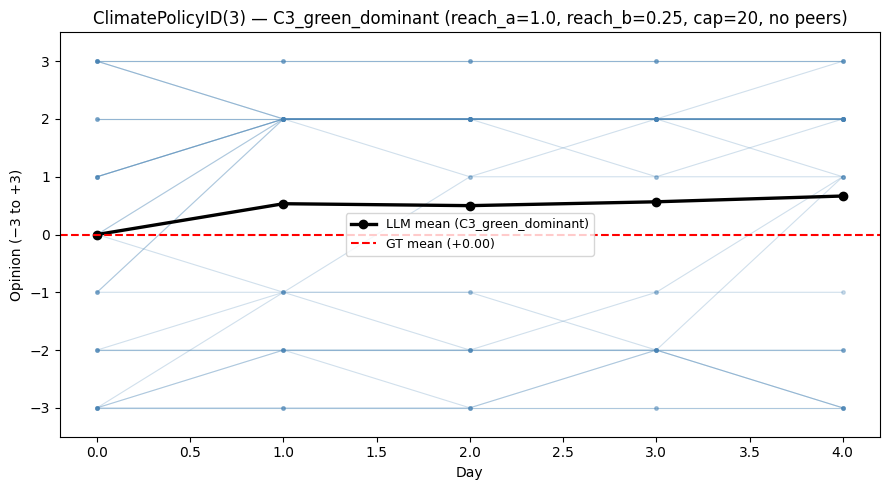

In [8]:
pdf = df_traj[df_traj["policy_id"].astype(str) == str(POLICY)]
gt_mean = gt_policy["ground_truth"].mean()

print(f"Mean opinion by day ({POLICY}):")
for day, val in pdf.groupby("day")["numeric"].mean().items():
    print(f"  Day {int(day)}: {val:+.2f}")
print(f"GT mean: {gt_mean:+.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
for aid, sub in pdf.groupby("agent_id"):
    sub = sub.sort_values("day")
    ax.plot(sub["day"], sub["numeric"], alpha=0.25, color="steelblue",
            linewidth=0.8, marker="o", markersize=2.5)
llm_mean = pdf.groupby("day")["numeric"].mean()
ax.plot(llm_mean.index, llm_mean.values, color="black", linewidth=2.4,
        marker="o", label=f"LLM mean ({CONDITION})")
ax.axhline(gt_mean, color="red", linestyle="--", linewidth=1.5,
           label=f"GT mean ({gt_mean:+.2f})")
ax.set_xlabel("Day")
ax.set_ylabel("Opinion (−3 to +3)")
ax.set_ylim(-3.5, 3.5)
ax.set_title(f"{POLICY} — {CONDITION} (reach_a={REACH_A}, reach_b={REACH_B}, cap={AUDIENCE_CAP}, no peers)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 7. Per-Exposure-Group Drift

The whole point of the broadcast-only design: A-only and B-only citizens should diverge cleanly because *only* the political broadcast can move them. Reconstruct exposure from `assign_political_exposure()` rules (cached on each citizen) and look at Day 0 → Day N drift per group.


In [9]:
exposure_map = {c.id: getattr(c, "political_exposure", "unknown")
                for c in sn.agents_active.values()}

pivot = pdf.pivot_table(index="agent_id", columns="day", values="numeric")
last_day = int(pdf["day"].max())
agent_drift = pd.DataFrame({
    "d0": pivot[0],
    f"d{last_day}": pivot[last_day],
    "drift": pivot[last_day] - pivot[0],
})
agent_drift["exposure"] = agent_drift.index.map(exposure_map)

print(f"Per-exposure-group drift Day 0 -> Day {last_day}  ({POLICY}, {CONDITION})\n")
agg = agent_drift.groupby("exposure").agg(
    n=("d0", "size"),
    d0_mean=("d0", "mean"),
    dN_mean=(f"d{last_day}", "mean"),
    drift_mean=("drift", "mean"),
    drift_sd=("drift", "std"),
).round(3)
print(agg.to_string())

print(f"\nPopulation: drift mean={agent_drift['drift'].mean():+.3f}, "
      f"sd={agent_drift['drift'].std():.3f}")
print(f"Movers (|drift|>=1): {(agent_drift['drift'].abs()>=1).sum()}/{len(agent_drift)}")


Per-exposure-group drift Day 0 -> Day 4  (ClimatePolicyID(3), C3_green_dominant)

           n  d0_mean  dN_mean  drift_mean  drift_sd
exposure                                            
A-only     6    0.500    1.500       1.000     1.265
B-only     5   -1.400   -1.800      -0.400     0.548
both      18    0.333    1.056       0.722     0.895
neither    1   -2.000    1.000       3.000       NaN

Population: drift mean=+0.667, sd=1.093
Movers (|drift|>=1): 17/30


## 8. Save Final Results + Plots + Timings


INFO Results saved to ../data/output/experiments/20260426_202955
INFO Plot saved to ../data/output/experiments/20260426_202955/opinion_trajectories.png
INFO Plot saved to ../data/output/experiments/20260426_202955/opinion_shares.png
WARNING No package index data to plot.
WARNING No package index share data to plot.



Results: ../data/output/experiments/20260426_202955
Plots:   2 files

=== Wall-time summary (1291.6s = 21.5 min) ===
               section     seconds
          build_nation    0.051564
   audience diagnostic    0.005017
  collect_ground_truth    0.001939
run_simulation (TOTAL) 1291.583312

Timings written to ../data/output/experiments/20260426_202955/timings.csv

Checkpoint dir (../data/output/experiments/21_bcastonly_C3_green_dominant) can now be deleted if desired.


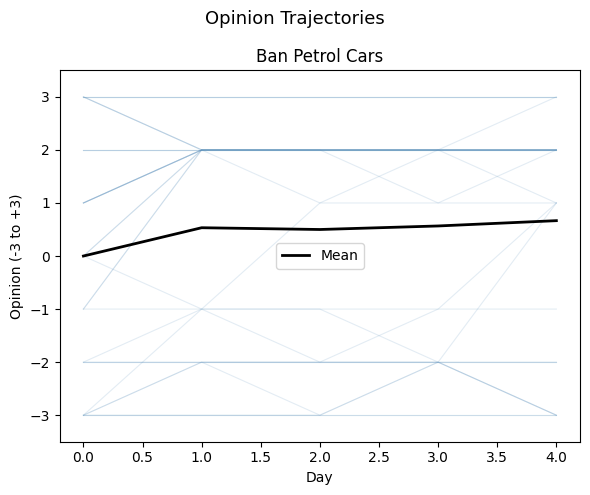

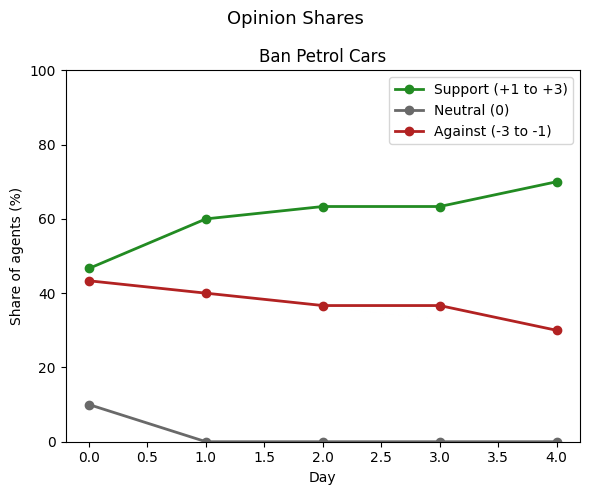

In [10]:
out_path = save_results(results, output_dir="../data/output/experiments")
plot_paths = save_result_plots(results, out_path)

timings_df = pd.DataFrame(TIMINGS, columns=["section", "seconds"])
total = timings_df["seconds"].sum()
timings_df.to_csv(out_path / "timings.csv", index=False)

(out_path / "CONDITION.txt").write_text(
    f"NB21 broadcast-only asymmetry\n"
    f"condition={CONDITION}\n"
    f"reach_a={REACH_A}\nreach_b={REACH_B}\naudience_cap={AUDIENCE_CAP}\n"
    f"policy={POLICY}\nn_citizens={N_CITIZENS}\nn_days={N_DAYS}\nseed={RANDOM_SEED}\n"
    f"phases=P-A,P-B (no peer C)\n"
)

print(f"\nResults: {out_path}")
print(f"Plots:   {len(plot_paths)} files")
print(f"\n=== Wall-time summary ({total:.1f}s = {total/60:.1f} min) ===")
print(timings_df.to_string(index=False))
print(f"\nTimings written to {out_path / 'timings.csv'}")
print(f"\nCheckpoint dir ({CHECKPOINT_DIR}) can now be deleted if desired.")


## 9. Cross-Condition Overlay

After all three conditions (`S_symmetric`, `C1_reform_dominant`, `C3_green_dominant`) have been run, this cell loads the latest output dir for each (matched by `CONDITION.txt` marker) and overlays their mean trajectories. If `S` sits between `C1` and `C3` and the gap is monotone in reach, the broadcast mechanism is doing its job.


  S_symmetric              -> ../data/output/experiments/20260426_185644
  C1_reform_dominant       -> ../data/output/experiments/20260426_192446
  C3_green_dominant        -> ../data/output/experiments/20260426_202955


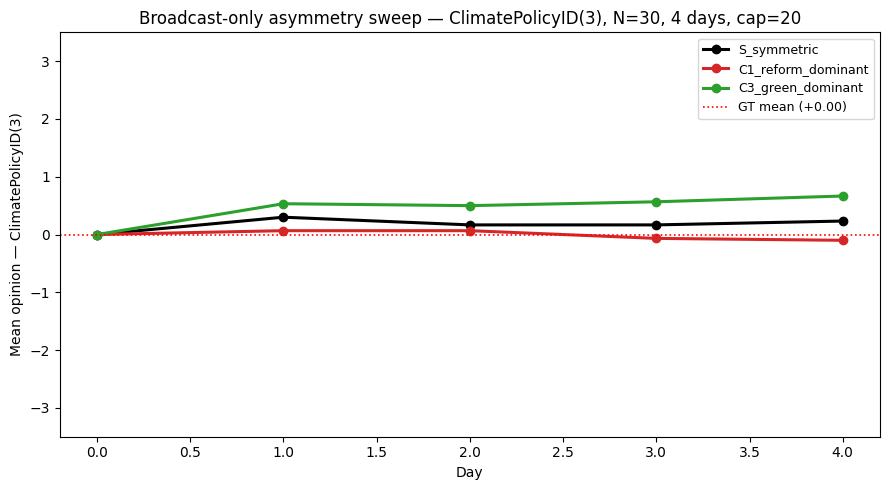


Mean opinion by day:
                    day_0  day_1  day_2  day_3  day_4
condition                                            
S_symmetric           0.0  0.300  0.167  0.167  0.233
C1_reform_dominant    0.0  0.067  0.067 -0.067 -0.100
C3_green_dominant     0.0  0.533  0.500  0.567  0.667


In [11]:
EXPERIMENTS_DIR = Path("../data/output/experiments")
TARGET_CONDITIONS = ["S_symmetric", "C1_reform_dominant", "C3_green_dominant"]

def find_latest_for(condition):
    """Most recent NB21 output dir whose CONDITION.txt matches `condition`."""
    candidates = []
    for d in EXPERIMENTS_DIR.iterdir():
        if not d.is_dir():
            continue
        marker = d / "CONDITION.txt"
        if not marker.exists():
            continue
        text = marker.read_text()
        if "NB21" in text and f"condition={condition}" in text:
            candidates.append(d)
    return max(candidates, default=None, key=lambda p: p.stat().st_mtime)

found = {c: find_latest_for(c) for c in TARGET_CONDITIONS}
for c, p in found.items():
    print(f"  {c:24s} -> {p}")

missing = [c for c, p in found.items() if p is None]
if missing:
    print(f"\nMissing condition outputs: {missing}. Run them first, then re-execute this cell.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = {"S_symmetric": "black",
              "C1_reform_dominant": "tab:red",
              "C3_green_dominant": "tab:green"}
    summary_rows = []
    for c, p in found.items():
        df = pd.read_csv(p / "opinion_trajectories.csv")
        df = df[df["policy_id"].astype(str) == str(POLICY)]
        mean = df.groupby("day")["numeric"].mean()
        ax.plot(mean.index, mean.values, color=colors[c], linewidth=2.2,
                marker="o", label=c)
        summary_rows.append({"condition": c, **{f"day_{int(d)}": v for d, v in mean.items()}})
    ax.axhline(gt_mean, color="red", linestyle=":", linewidth=1.2,
               label=f"GT mean ({gt_mean:+.2f})")
    ax.set_xlabel("Day")
    ax.set_ylabel(f"Mean opinion — {POLICY}")
    ax.set_ylim(-3.5, 3.5)
    ax.set_title(f"Broadcast-only asymmetry sweep — {POLICY}, N={N_CITIZENS}, {N_DAYS} days, cap={AUDIENCE_CAP}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print("\nMean opinion by day:")
    print(pd.DataFrame(summary_rows).set_index("condition").round(3).to_string())
